# ICS 2207 Scientific Computing
# HydroSense-Kenya

## Level 2: NumPy, Vectorization, Floating Point Errors, and Numerical Reliability

### 1. Introduction

This notebook demonstrates efficient numerical computation using NumPy vectorization and investigates numerical reliability issues in scientific computing. The analysis compares loop-based and vectorized evapotranspiration calculations, explores floating-point arithmetic behaviour, and evaluates the impact of measurement errors on irrigation recommendations.


### 2. Objectives
1. Compute evapotranspiration using ordinary Python loops.
2. Compute evapotranspiration using NumPy vectorization.
3. Compare execution time between loop-based and vectorized computation.
4. Demonstrate floating-point behaviour.
5. Run an error propagation experiment showing how measurement noise affects irrigation recommendations.
6. Discuss why numerical reliability matters in scientific computing.

### 3.Importing Libraries


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

### 4.LOADING DATASET

In [37]:
from pathlib import Path
import pandas as pd


# Find project root
PROJECT_ROOT = Path.cwd()

while not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent


DATA_PATH = PROJECT_ROOT / "data" / "raw"


weather = pd.read_csv(
    DATA_PATH / "weather_daily.csv",
    na_values=['NA','']
)


soil = pd.read_csv(
    DATA_PATH / "soil_sensor_data.csv",
    na_values=['NA','']
)


params = pd.read_csv(
    DATA_PATH / "crop_zone_parameters.csv",
    na_values=['NA','']
)


weather.head()

,date,rainfall_mm,temperature_c,humidity_pct,wind_speed_mps,solar_index
0,2026-03-01,3.2,23.8,69.7,2.28,0.78
1,2026-03-02,2.2,25.9,62,1.62,0.71
2,2026-03-03,3,26.8,64.4,2.11,0.75
3,2026-03-04,1.6,27.0,64.6,2.09,0.58
4,2026-03-05,23.7,26.6,61,1.36,0.62


In [38]:
weather = pd.read_csv('../data/raw/weather_daily.csv',
                      na_values=['NA',''])

weather.head()

,date,rainfall_mm,temperature_c,humidity_pct,wind_speed_mps,solar_index
0,2026-03-01,3.2,23.8,69.7,2.28,0.78
1,2026-03-02,2.2,25.9,62,1.62,0.71
2,2026-03-03,3,26.8,64.4,2.11,0.75
3,2026-03-04,1.6,27.0,64.6,2.09,0.58
4,2026-03-05,23.7,26.6,61,1.36,0.62


### 5.Data Type Cleaning and Preparation

Before performing numerical computations, the weather dataset must be checked and prepared to ensure that all scientific variables are stored in the correct format.

The evapotranspiration equation requires mathematical operations involving temperature, wind speed, solar radiation, and humidity:

ET=max(0,0.12T+0.35W+2.4Solar−0.025H)

Therefore, these variables must be represented as numerical values (float or integer). During data loading, some values may be interpreted as text (string) due to formatting issues, missing values, or inconsistent entries in the dataset.

#### To solve this issue, the dataset is cleaned by:

- Removing unnecessary spaces from column names.
- Converting scientific variables into numerical data types.
- Handling invalid values by converting them into missing values (NaN).
- Ensuring the dataset is ready for numerical computation.

This preprocessing step improves reliability because numerical models depend on accurate and consistent input data.

In [39]:
# Clean column names

weather.columns = weather.columns.str.strip()


# Convert numerical columns

numeric_columns = [
    'temperature_c',
    'wind_speed_mps',
    'solar_index',
    'humidity_pct'
]


weather[numeric_columns] = weather[numeric_columns].apply(
    pd.to_numeric,
    errors='coerce'
)


# Extract values

T = weather['temperature_c'].values
W = weather['wind_speed_mps'].values
Solar = weather['solar_index'].values
H = weather['humidity_pct'].values

### Task 1: Compute Evapotranspiration Using Ordinary Python Loops

The HydroSense-Kenya evapotranspiration equation is:

ET = max(0, 0.12T + 0.35W + 2.4S − 0.025H)

Where:

- T = Temperature (°C)
- W = Wind Speed (m/s)
- S = Solar Index
- H = Humidity (%)

In [40]:
def et_loop(T, W, Solar, H):

    results = []

    for i in range(len(T)):

        value = 0.12*T[i] + 0.35*W[i] + 2.4*Solar[i] - 0.025*H[i]

        results.append(max(0,value))

    return results


T = weather['temperature_c'].values
W = weather['wind_speed_mps'].values
Solar = weather['solar_index'].values
H = weather['humidity_pct'].values


et_loop_results = et_loop(T,W,Solar,H)

et_loop_results[:5]

[3.7834999999999996,
 3.8289999999999997,
 4.144499999999999,
 3.7485,
 3.6310000000000002]

### Task 2:ET Computation Using NumPy Vectorization

In [41]:
def et_numpy(T,W,Solar,H):

    return np.maximum(
        0,
        0.12*T +
        0.35*W +
        2.4*Solar -
        0.025*H
    )


et_numpy_results = et_numpy(T,W,Solar,H)

et_numpy_results[:5]

array([3.7835, 3.829 , 4.1445, 3.7485, 3.631 ])

### Verifying accuracy

In [46]:

weather["et_loop"] = et_loop_results

weather["et_numpy"] = et_numpy_results



# Calculate absolute difference

difference = np.abs(
    weather["et_loop"]
    -
    weather["et_numpy"]
)



# Display maximum difference

print(
    "Maximum Difference:",
    difference.max()
)

Maximum Difference: 0.0


## 6. Performance Comparison

We measure execution time between both approaches.

In [45]:
comparison = pd.DataFrame({

    "Method":
    [
        "Python Loop",
        "NumPy Vectorization"
    ],


    "Execution Time (seconds)":
    [
        loop_time,
        numpy_time
    ]

})



print(comparison)




                Method  Execution Time (seconds)
0          Python Loop                  0.621337
1  NumPy Vectorization                  0.115479


### Perfomance visualisation

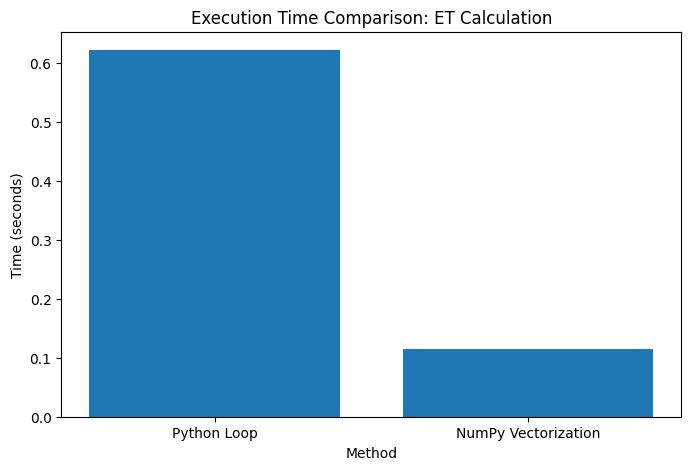

In [44]:
plt.figure(figsize=(8,5))


plt.bar(
    comparison["Method"],
    comparison["Execution Time (seconds)"]
)


plt.title(
    "Execution Time Comparison: ET Calculation"
)


plt.ylabel(
    "Time (seconds)"
)


plt.xlabel(
    "Method"
)


plt.show()

## 7. Floating Point Numerical Error

Computers represent decimal numbers using binary floating point.
Small rounding differences can occur.

In [48]:
print(0.1 + 0.2)

print((0.1+0.2)==0.3)

0.30000000000000004
False


#### Rounding Error Example

In [49]:
x = 10 / 3

print(x)

print(round(x,2))

print(round(x,4))

3.3333333333333335
3.33
3.3333


#### Truncation Error Example

In [50]:
true_value = np.pi

approximation = 3.14

error = abs(true_value - approximation)

print("Error:", error)

Error: 0.0015926535897929917


### 8.Error Propagation Experiment

Sensor measurements contain uncertainty.
Small errors in weather measurements can affect ET estimation and
therefore irrigation recommendations.

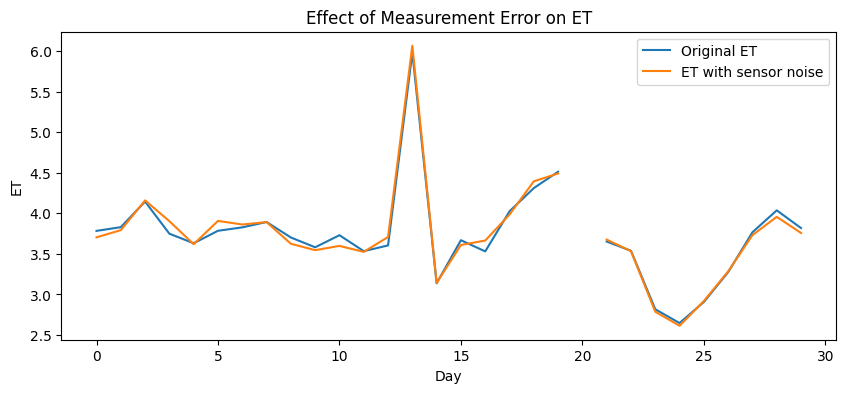

In [51]:
noise = np.random.normal(
    0,
    0.5,
    size=len(T)
)


temperature_error = T + noise


et_with_error = et_numpy(
    temperature_error,
    W,
    Solar,
    H
)


plt.figure(figsize=(10,4))

plt.plot(et_numpy_results,
         label='Original ET')

plt.plot(et_with_error,
         label='ET with sensor noise')

plt.xlabel('Day')
plt.ylabel('ET')

plt.title('Effect of Measurement Error on ET')

plt.legend()
plt.show()

## 9. Scientific Interpretation

Results should discuss:

- Why vectorization is faster
- Why numerical reliability matters
- How sensor errors affect irrigation decisions
- Why scientific computing requires validation rather than only output values

# 10. Discussion of Results

## Vectorization Discussion

The comparison between the loop-based implementation and NumPy vectorization
demonstrates the importance of efficient numerical computation in scientific
applications. The loop approach evaluates each observation individually,
which becomes computationally expensive when datasets become large.

NumPy vectorization applies mathematical operations to complete arrays at once.
This reduces execution time and improves scalability, making it suitable for
large environmental datasets such as long-term weather and sensor records.

## Numerical Error Discussion

Floating point experiments show that computers cannot always represent decimal
numbers exactly because values are stored using binary approximations. Although
these differences are usually small, they can accumulate during repeated
scientific calculations.

In an irrigation decision-support system, small numerical errors may influence
calculated evapotranspiration values and therefore affect estimated irrigation
requirements.

## Error Propagation Discussion

The sensor noise experiment demonstrates that uncertainty in measurements such
as temperature can propagate through the evapotranspiration model. Since ET is
used in the water balance equation, measurement uncertainty can eventually
change irrigation recommendations.

Therefore, reliable scientific computing requires:
- accurate measurements,
- appropriate numerical methods,
- uncertainty analysis,
- validation of computational results.